In [17]:
from __future__ import unicode_literals, print_function, division
import unicodedata
import re


#from io import open
#import string
#
#import torch.nn as nn
#
#

SOS_token = 0
EOS_token = 1

class Lang:
# 定义一个Lang类（Language），用于管理词汇表、词汇到索引的映射、以及词频计数。
    def __init__(self, name):
        self.name = name
        # 存储语言名称（如 'eng' 或 'fra'）。
        self.word2index = {}
        # 字典：存储词语到其整数索引的映射（用于模型输入）。
        self.word2count = {}
        # 字典：存储每个词语出现的次数（用于词频统计和可选的过滤）。
        self.index2word = {0: "SOS", 1: "EOS"}
        # 字典：存储整数索引到词语的映射。初始化时已包含SOS和EOS标记。
        self.n_words = 2  # Count SOS and EOS
        # 词汇表中的词语总数。从2开始计数（已包含SOS和EOS）。

    def addSentence(self, sentence):
    # 方法：将句子中的所有词语添加到词汇表中。
        for word in sentence.split(' '):
        # 按空格分割句子，迭代每个词语。
            self.addWord(word)
            # 调用addWord方法处理单个词语。

    def addWord(self, word):
    # 方法：处理单个词语，更新词汇表和计数。
        if word not in self.word2index:
        # 如果词语是新的，尚未在词汇表中。
            self.word2index[word] = self.n_words
            # 为新词分配当前的n_words作为索引。
            self.word2count[word] = 1
            # 初始化该词的计数为1。
            self.index2word[self.n_words] = word
            # 将新索引和词语添加到index2word映射中。
            self.n_words += 1
            # 词汇表大小加1。
        else:
        # 如果词语已经存在。
            self.word2count[word] += 1
            # 仅增加该词的计数。

# Turn a Unicode string to plain ASCII, thanks to
def unicodeToAscii(s):
    # 函数：将Unicode字符串转换为纯ASCII字符串。
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        # 第一步：使用 'NFD'（Normalization Form Decomposition）进行规范化。
        # 它将字符分解为基字符和组合标记（例如，'é'分解为'e'和重音符）。
        if unicodedata.category(c) != 'Mn'
        # 第二步：过滤掉类别为 'Mn' (Mark, Nonspacing) 的字符。
        # 也就是移除非间距标记（如重音、音调符号等），实现“去重音”效果。
    )
# ---

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    # 函数：对单个字符串进行标准化处理（清理文本）。
    s = unicodeToAscii(s.lower().strip())
    # 步骤1：转换为ASCII，转换为小写，并去除首尾空白。
    s = re.sub(r"([.!?])", r" \1", s)
    # 步骤2：使用正则表达式在标点符号 (.!?) 前面添加一个空格。
    # 这样，在后续的split(' ')操作中，标点符号会被视作独立的“词语”。
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    # 步骤3：移除所有非字母、非标点符号的字符，替换为单个空格。
    # 清理掉数字、括号、特殊符号等。
    return s

def readLangs(lang1, lang2, reverse=False):
    # 函数：读取语言数据文件，并进行初步处理。
    print("Reading lines...")
    # Read the file and split into lines
    lines = open('data/%s-%s.txt' % (lang1, lang2), encoding='utf-8').\
        read().strip().split('\n')
    # 步骤1：打开并读取数据文件
    # 以 UTF-8 编码读取，去除首尾空白，然后按换行符分割成列表。
    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')[:2]] for l in lines]
    # 步骤2：遍历每一行（每一对句子）。
    # l.split('\t')[:2]：按制表符（\t）分割，只取前两列（输入和输出句子）。
    # 对每对句子中的两个字符串都调用 normalizeString 进行清洗。
    # Reverse pairs, make Lang instances #正反互换翻译
    if reverse:
        # 如果设置了 reverse=True，则交换句子对的顺序（用于反向翻译，例如从法语翻译到英语）。
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        # 此时，输入语言是第二个语言（lang2）。
        output_lang = Lang(lang1)
        # 输出语言是第一个语言（lang1）。
    else:
        # 默认顺序：lang1 -> lang2。
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)
    return input_lang, output_lang, pairs
    # 返回初始化后的Lang对象和清洗后的句子对列表。


def filterPair(p,MAX_LENGTH,eng_prefixes):
    # 函数：检查单个句子对是否满足筛选条件。
    return len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH and  p[1].startswith(eng_prefixes)
        # 条件1：输入句子（p[0]）的词数小于最大长度限制。
        # 条件2：输出句子（p[1]）的词数小于最大长度限制。
        # 条件3：输出句子（这里通常是英语）以预定义的常用短语开头（例如：'I am ', 'You are '）。
        # 这是为了减少训练集大小和复杂度，只专注于简单的句子。

def filterPairs(pairs,MAX_LENGTH,eng_prefixes):
    # 函数：应用 filterPair 对所有句子对进行批量筛选。
    return [pair for pair in pairs if filterPair(pair,MAX_LENGTH,eng_prefixes)]
    # 使用列表推导式，只保留满足 filterPair 条件的句子对。

def prepareData(lang1, lang2, MAX_LENGTH ,eng_prefixes, reverse=False):
    # 核心函数：协调所有预处理步骤，准备最终的训练数据。
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    # 步骤1：读取文件，进行基本清理，并根据 reverse 确定输入/输出语言。
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs,MAX_LENGTH,eng_prefixes)
    # 步骤2：根据最大长度和前缀条件筛选句子对。
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
    # 步骤3：遍历所有筛选后的句子对，构建词汇表（计数词语）。
        input_lang.addSentence(pair[0])
        # 将输入句子中的所有词添加到 input_lang 的词汇表中。
        output_lang.addSentence(pair[1])
        # 将输出句子中的所有词添加到 output_lang 的词汇表中。
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    # 打印输入语言的名称和词汇表大小。
    print(output_lang.name, output_lang.n_words)
    # 打印输出语言的名称和词汇表大小。

    return input_lang, output_lang, pairs
    # 返回最终的输入语言 Lang 对象、输出语言 Lang 对象和筛选后的句子对。

def indexesFromSentence(lang, sentence):
    # 函数：将句子（字符串）转换为对应的词汇索引列表（Python list of integers）。
    return [lang.word2index[word] for word in sentence.split(' ')]
    # 使用列表推导式：
    # 1. sentence.split(' ')：按空格将句子拆分成词语列表。
    # 2. lang.word2index[word]：查找 Lang 实例中每个词语对应的整数索引。

def tensorFromSentence(lang, sentence):
    # 函数：将句子转换为 PyTorch 张量（Tensor），并添加 EOS 标记。
    indexes = indexesFromSentence(lang, sentence)
    # 步骤1：将句子转换为词汇索引列表。
    indexes.append(EOS_token)
    # 步骤2：在序列末尾添加“序列结束” (EOS) 标记的索引（值为 1）。
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)
    # 步骤3：将索引列表转换为 PyTorch 张量。
    # - dtype=torch.long：确保数据类型为长整型，这是索引和序列输入的标准类型。
    # - device=device：将张量移动到先前定义的设备（CPU 或 GPU）。
    # - .view(-1, 1)：重塑张量。Seq2Seq 模型通常要求输入是 (序列长度, 1) 的形状，
    #   其中 1 代表批次大小（这里是 1，因为每次只处理一个句子）。

def tensorsFromPair(pair):
    # 函数：将一个句子对（[输入句子, 目标句子]）转换为输入和目标张量对。
    # 注意：这个函数依赖于全局变量 input_lang 和 output_lang。
    input_tensor = tensorFromSentence(input_lang, pair[0])
    # 步骤1：将句子对的第一个元素（输入句子）转换为张量。
    target_tensor = tensorFromSentence(output_lang, pair[1])
    # 步骤2：将句子对的第二个元素（目标句子）转换为张量。
    return (input_tensor, target_tensor)
    # 返回包含输入张量和目标张量的元组，可直接用于模型训练。


In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
from sklearn.model_selection import train_test_split
#generate the train test set

MAX_LENGTH = 15
eng_prefixes = (
    "i am", "i m",
    "he is", "he s",
    "she is", "she s",
    "you are", "you re",
    "we are", "we re",
    "they are", "they re"
)
#data prepare
input_lang, output_lang, pairs = prepareData('eng', 'fra', MAX_LENGTH,eng_prefixes, True)
X = [i[0] for i in pairs]
y = [i[1] for i in pairs]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
train_pairs = list(zip(X_train,y_train))
test_pairs = list(zip(X_test,y_test))
#print an example
print(train_pairs[0])
print(test_pairs[0])

Reading lines...
Read 239189 sentence pairs
Trimmed to 23543 sentence pairs
Counting words...
Counted words:
fra 7142
eng 4737
('nous n en avons pas termine .', 'we re not done .')
('il aurait du travailler plus .', 'he should have worked harder .')


In [60]:
import torch.nn as nn
import torch.nn.functional as F

class EncoderRNN(nn.Module):
    # 定义编码器类，继承自 nn.Module
    def __init__(self, input_size, hidden_size):
        # 构造函数：input_size 是输入词汇表大小，hidden_size 是隐藏层维度
        super(EncoderRNN, self).__init__()
        # 调用父类构造函数
        self.hidden_size = hidden_size
        # 存储隐藏层大小
        self.embedding = nn.Embedding(input_size, hidden_size)
        # 嵌入层：将输入词元（索引）映射到稠密的 hidden_size 维向量
        self.gru = nn.GRU(hidden_size, hidden_size)
        # GRU层：核心循环单元，输入和输出维度都是 hidden_size
    def forward(self, input, hidden):
        # 前向传播函数：处理单个输入词元
        # input: 当前时间步的输入词元（索引），形状通常为 (1)
        # hidden: 上一时间步的隐藏状态，形状 (1, 1, hidden_size)
        embedded = self.embedding(input).view(1, 1, -1)
        # 1. 嵌入：查找嵌入向量
        # 2. 塑形：将嵌入向量从 (1, hidden_size) [embedding 的输出] 塑形为 GRU 期望的 (seq_len=1, batch_size=1, hidden_size)
        output = embedded
        # 初始 GRU 输入为嵌入向量
        output, hidden = self.gru(output, hidden)
        # 通过 GRU 单元：计算新的输出和新的隐藏状态
        # output: 当前时间步的输出 (通常被忽略)
        # hidden: GRU 的最终隐藏状态 (包含上下文信息)
        return output, hidden
        # 返回 GRU 输出和更新后的隐藏状态（上下文向量）
    def initHidden(self):
        # 初始化隐藏状态函数
        return torch.zeros(1, 1, self.hidden_size, device=device)
        # 返回一个全零张量作为初始隐藏状态，形状 (num_layers=1, batch_size=1, hidden_size)



In [61]:
class Decoder(nn.Module):
    # 定义解码器类
    def __init__(self, hidden_size, output_size):
        # 构造函数：hidden_size 是隐藏层维度，output_size 是输出词汇表大小
        super(Decoder, self).__init__()
        # 调用父类构造函数
        self.hidden_size = hidden_size
        # 存储隐藏层大小
        self.embedding = nn.Embedding(output_size, hidden_size)
        # 嵌入层：将目标词元（索引）映射到 hidden_size 维向量
        self.gru = nn.GRU(hidden_size, hidden_size)
        # GRU层：核心循环单元，输入和输出维度都是 hidden_size
        self.out = nn.Linear(hidden_size, output_size)
        # 线性层：将 GRU 的隐藏状态映射到输出词汇表的维度
        self.softmax = nn.LogSoftmax(dim=1)
        # LogSoftmax：将线性层的输出转换为对数概率（Log-probabilities），通常用于计算损失。

    def forward(self, input, hidden):
        # 前向传播函数：解码器的一个时间步
        # input: 当前时间步的输入词元（通常是上一步的预测结果或教师强制的真实标签）
        # hidden: 当前时间步的隐藏状态（初始时为编码器的上下文向量）

        output = self.embedding(input).view(1, 1, -1)
        # 1. 嵌入：查找输入词元的嵌入向量
        # 2. 塑形：从 (1, hidden_size) 塑形为 (seq_len=1, batch_size=1, hidden_size)
        output = F.relu(output)
        # 应用 ReLU 激活函数（在 GRU 之前使用是可选的设计）
        output, hidden = self.gru(output, hidden)
        # 通过 GRU 单元：处理当前输入词元和隐藏状态，得到新的输出和隐藏状态
        # --- 下面是关键的输出处理部分 ---
        output_for_linear = output.squeeze(0) # 修正或优化点：从 (1, 1, H) 变为 (1, H)
        # 为了清晰和健壮，推荐使用 .squeeze(0) 来移除序列长度为 1 的维度。
        output = self.softmax(self.out(output_for_linear))
        # 1. self.out(...)：将 (1, hidden_size) 映射到 (1, output_size)
        # 2. self.softmax(...)：应用 LogSoftmax，得到预测词元的对数概率
        return output, hidden
        # 返回预测的词元概率对数和更新后的隐藏状态

    def initHidden(self):
        # 初始化隐藏状态函数
        return torch.zeros(1, 1, self.hidden_size, device=device)
        # 返回一个全零张量作为初始隐藏状态（通常在 Seq2Seq 中不使用，而是接收编码器的输出）


In [69]:
import time
import math
from torch import optim
import random
from torchmetrics.text.rouge import ROUGEScore
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

def train(teacher_forcing_ratio, input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, max_length=MAX_LENGTH):
    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    loss = 0
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_input = torch.tensor([[SOS_token]], device=device)

    decoder_hidden = encoder_hidden

    use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

    if use_teacher_forcing:
        # Teacher forcing: Feed the target as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(
                decoder_input, decoder_hidden)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di]  # Teacher forcing

    else:
        # Without teacher forcing: use its own predictions as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(
                decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach()  # detach from history as input

            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

def trainIters(teacher_forcing_ratio, encoder, decoder, epochs, print_every=1000, plot_loss_path=None, learning_rate=0.01, save_checkpoints_path=None):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0   # Reset every plot_every
    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)

    criterion = nn.NLLLoss()

    iter = 1
    n_iters = len(train_pairs) * epochs
    for epoch in range(epochs):
        print("Epoch: %d/%d" % (epoch, epochs))
        for training_pair in train_pairs:
            training_pair = tensorsFromPair(training_pair)

            input_tensor = training_pair[0]
            target_tensor = training_pair[1]

            loss = train(teacher_forcing_ratio, input_tensor, target_tensor, encoder,
                        decoder, encoder_optimizer, decoder_optimizer, criterion)
            print_loss_total += loss
            plot_loss_total += loss
            plot_losses.append(loss)

            if iter % print_every == 0:
                print_loss_avg = print_loss_total / print_every
                print_loss_total = 0
                print('%s (%d %d%%) %.4f' % (timeSince(start, iter / n_iters),iter, iter / n_iters * 100, print_loss_avg))
            iter +=1

        if save_checkpoints_path!=None:
            save_path=save_checkpoints_path+'/'+'checkpoint_epoch_'+str(epoch)+'.pth'
            save_checkpoint(epoch, encoder, decoder, encoder_optimizer, decoder_optimizer, print_loss_avg, save_path)

    if plot_loss_path != None:
                np.random.seed(42) # 为了结果可复现
                raw_loss_list = plot_losses

                loss_series = pd.Series(raw_loss_list)
                WINDOW_SIZE = 20 # 平滑窗口大小
                smoothed_loss = loss_series.rolling(window=WINDOW_SIZE, min_periods=1).mean()

                DESIRED_POINTS = 1000 # 例如，希望图上只有 200 个点

                total_steps = len(raw_loss_list)
                if total_steps > DESIRED_POINTS:
                    # 计算需要跳过的步长
                    sample_step = total_steps // DESIRED_POINTS
                    # 或者可以使用 np.linspace 来获取精确的索引
                    sample_indices = np.linspace(0, total_steps - 1, DESIRED_POINTS, dtype=int)
                else:
                 # 如果总点数少于或等于期望点数，则不采样，绘制所有点
                    sample_indices = np.arange(total_steps)
                    sample_step = 1 # 方便理解，实际不会用到
                sampled_steps = sample_indices
                sampled_raw_loss = [raw_loss_list[i] for i in sample_indices]
                sampled_smoothed_loss = [smoothed_loss[i] for i in sample_indices]
                plt.figure(figsize=(12, 6))
                if total_steps > DESIRED_POINTS: # 只有当采样发生时才绘制采样点
                    plt.plot(sampled_steps, sampled_raw_loss,
                             label='Raw Loss (Sampled)',
                             color='lightgray',
                             linestyle='--',
                             alpha=0.6,
                             marker='.', # 可以添加点标记来强调是采样点
                             markersize=4)


                plt.plot(sampled_steps, sampled_smoothed_loss,
                        label=f'Smoothed Loss (Window={WINDOW_SIZE}, {len(sampled_steps)} points)',
                         color='red',
                        linewidth=2)

                plt.title('Training Loss Curve (Sampled Points)', fontsize=16)
                plt.xlabel('Training Steps', fontsize=14)
                plt.ylabel('Loss Value', fontsize=14)
                plt.legend()
                plt.grid(True)
                #plt.show()
                plt.savefig(plot_loss_path+'/training_loss_curve.png')

                #保存所有最终loss值
                with open(plot_loss_path+'/training_loss_curve.pkl', 'wb') as f:
                    pickle.dump(plot_losses, f)


def evaluate(encoder, decoder, sentence, max_length=MAX_LENGTH):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        input_length = input_tensor.size()[0]
        encoder_hidden = encoder.initHidden()
        encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei],encoder_hidden)
            encoder_outputs[ei] += encoder_output[0, 0]
        decoder_input = torch.tensor([[SOS_token]], device=device)  # SOS
        decoder_hidden = encoder_hidden
        decoded_words = []
        for di in range(max_length):
            decoder_output, decoder_hidden = decoder(
                decoder_input, decoder_hidden)
            topv, topi = decoder_output.data.topk(1)
            if topi.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(output_lang.index2word[topi.item()])
            decoder_input = topi.squeeze().detach()

        return decoded_words

def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words = evaluate(encoder, decoder, pair[0])
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

def inference(encoder, decoder, testing_pairs):
    input = []
    gt = []
    predict = []
    from tqdm import tqdm
    for i in tqdm(range(len(testing_pairs))):
        pair = testing_pairs[i]
        output_words = evaluate(encoder, decoder, pair[0])
        output_sentence = ' '.join(output_words)
        input.append(pair[0])
        gt.append(pair[1])
        predict.append(output_sentence)

    return input,gt,predict

def save_checkpoint(epoch, encoder, decoder, encoder_optimizer, decoder_optimizer, loss, filepath):
    """保存模型的检查点（checkpoint）"""
    torch.save({
        'epoch': epoch,
        'encoder_state_dict': encoder.state_dict(),
        'decoder_state_dict': decoder.state_dict(),
        'encoder_optimizer_state_dict': encoder_optimizer.state_dict(),
        'decoder_optimizer_state_dict': decoder_optimizer.state_dict(),
        'loss': loss,
    }, filepath)

def eval(gt, predict):
  rouge = ROUGEScore()
  metric_score = rouge(predict, gt)
  print("=== Evaluation score - Rouge score ===")
  print("Rouge1 fmeasure:\t",metric_score["rouge1_fmeasure"].item())
  print("Rouge1 precision:\t",metric_score["rouge1_precision"].item())
  print("Rouge1 recall:  \t",metric_score["rouge1_recall"].item())
  print("Rouge2 fmeasure:\t",metric_score["rouge2_fmeasure"].item())
  print("Rouge2 precision:\t",metric_score["rouge2_precision"].item())
  print("Rouge2 recall:  \t",metric_score["rouge2_recall"].item())
  print("=====================================")

Epoch: 0/5
1m 46s (- 35m 59s) (5000 4%) 3.3247
3m 50s (- 36m 49s) (10000 9%) 2.8597
5m 38s (- 34m 13s) (15000 14%) 2.6314
7m 17s (- 31m 18s) (20000 18%) 2.4482
Epoch: 1/5
8m 41s (- 28m 8s) (25000 23%) 2.2404
10m 7s (- 25m 37s) (30000 28%) 2.0809
11m 18s (- 22m 55s) (35000 33%) 1.9883
12m 22s (- 20m 23s) (40000 37%) 1.8961
Epoch: 2/5
13m 27s (- 18m 14s) (45000 42%) 1.7964
14m 33s (- 16m 17s) (50000 47%) 1.6743
15m 41s (- 14m 32s) (55000 51%) 1.6163
16m 49s (- 12m 53s) (60000 56%) 1.5359
Epoch: 3/5
18m 18s (- 11m 32s) (65000 61%) 1.4963
20m 1s (- 10m 16s) (70000 66%) 1.3988
21m 49s (- 9m 0s) (75000 70%) 1.3447
23m 36s (- 7m 39s) (80000 75%) 1.2775
Epoch: 4/5
25m 27s (- 6m 16s) (85000 80%) 1.2775
27m 0s (- 4m 46s) (90000 84%) 1.1858
28m 23s (- 3m 16s) (95000 89%) 1.1423
29m 33s (- 1m 45s) (100000 94%) 1.1060
30m 50s (- 0m 16s) (105000 99%) 1.0993


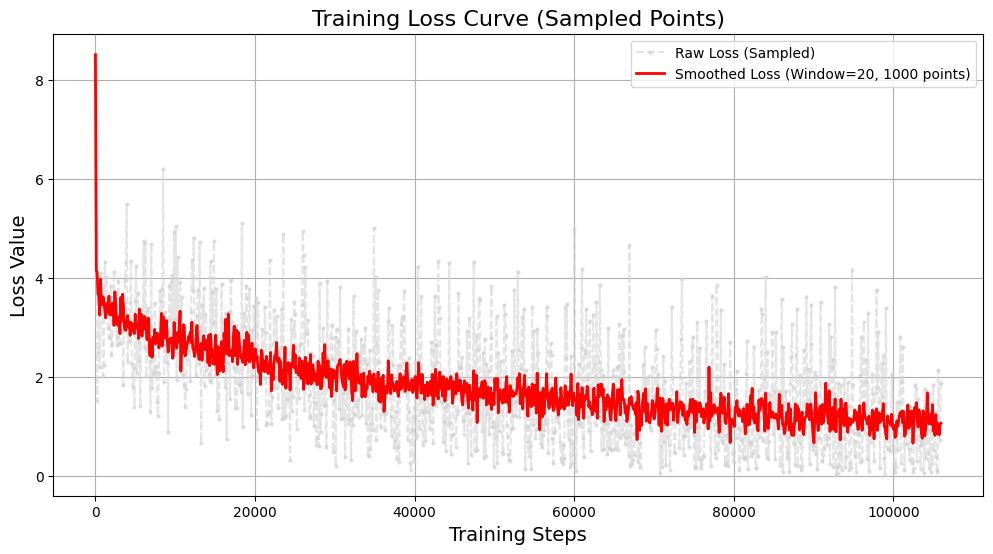

In [76]:
#begin training
#TASK.1 GRU
hidden_size = 256
teacher_forcing_ratio=0.5
epochs = 5
save_checkpoints_path='./checkpoints/task1'
plot_loss_path='./checkpoints/task1'

#to conotinue from interrupted process 注释以下两行来阻止编码器和解码器初始化
encoder1 = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder1 = Decoder(hidden_size, output_lang.n_words).to(device)
trainIters(teacher_forcing_ratio=teacher_forcing_ratio, encoder=encoder1, decoder=decoder1,
           epochs=epochs, print_every=5000, plot_loss_path=plot_loss_path, learning_rate=0.01,save_checkpoints_path=save_checkpoints_path)


In [ ]:
evaluateRandomly(encoder1, decoder1)
input,gt,predict = inference(encoder1, decoder1, test_pairs)
eval(gt, predict)

In [75]:
with open('./checkpoints/task1/training_loss_curve.pkl', 'rb') as f:
    # 使用 load() 从文件读取列表
    loaded_list = pickle.load(f)
print(len(loaded_list))


21188


In [81]:
#load from check point
hidden_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = './checkpoints/task1/checkpoint_epoch_4.pth'

encoder1 = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder1 = Decoder(hidden_size, output_lang.n_words).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
encoder1.load_state_dict(checkpoint['encoder_state_dict'])
decoder1.load_state_dict(checkpoint['decoder_state_dict'])

evaluateRandomly(encoder1, decoder1)
input,gt,predict = inference(encoder1, decoder1, test_pairs)
eval(gt, predict)

> ce que vous pensez ne m interesse guere .
= i m not interested in what you think .
< i m not interested in you what i m . <EOS>

> nous sommes du meme tonneau .
= we are two of a kind .
< we re a of of . . . . <EOS>

> je suis sur de ma decision a .
= i m sure of my decision .
< i m sure of my decision . <EOS>

> j ai chaud dans ce manteau .
= i m hot in this coat .
< i m on the wrong this . <EOS>

> j ai bien peur de vous devoir des excuses .
= i m afraid that i owe you an apology .
< i m afraid that i you . <EOS>

> je vais tenter ma chance .
= i m going to take my chances .
< i m going to take my my . <EOS>

> nous nous battons encore .
= we re still fighting .
< we re still shopping . <EOS>

> je ne vais pas t attaquer en justice .
= i m not going to sue you .
< i m not going to you you . <EOS>

> nous n en sommes pas si surs .
= we re not so sure .
< we re not so sure . <EOS>

> il est le garcon le plus apprecie de la classe .
= he s the most popular boy in the class .
< he s th

100%|██████████| 2355/2355 [00:11<00:00, 205.04it/s]


=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.620948851108551
Rouge1 precision:	 0.5874614119529724
Rouge1 recall:  	 0.6673239469528198
Rouge2 fmeasure:	 0.4391239881515503
Rouge2 precision:	 0.4075421690940857
Rouge2 recall:  	 0.48498106002807617


In [77]:
class Encoder_LSTM(nn.Module):
    # 定义编码器类，继承自 nn.Module
    def __init__(self, input_size, hidden_size):
        # 构造函数：input_size 是输入词汇表大小，hidden_size 是隐藏层维度
        super(Encoder_LSTM, self).__init__()
        # 调用父类构造函数
        self.hidden_size = hidden_size
        # 存储隐藏层大小
        self.embedding = nn.Embedding(input_size, hidden_size)
        # 嵌入层：将输入词元（索引）映射到稠密的 hidden_size 维向量
        self.lstm = nn.LSTM(hidden_size, hidden_size)
        # LSTM层：核心循环单元，输入和输出维度都是 hidden_size

    def forward(self, input, hidden_and_cell):
        # 前向传播函数：处理单个输入词元
        # input: 当前时间步的输入词元（索引），形状通常为 (1)
        # hidden: 上一时间步的隐藏状态，形状 (1, 1, hidden_size)
        embedded = self.embedding(input).view(1, 1, -1)
        # 1. 嵌入：查找嵌入向量
        # 2. 塑形：将嵌入向量从 (1, hidden_size) [embedding 的输出] 塑形为 GRU 期望的 (seq_len=1, batch_size=1, hidden_size)
        output = embedded
        # 初始 LSTM 输入为嵌入向量
        output, hidden_and_cell = self.lstm(output, hidden_and_cell)
        # 通过 LSTM 单元：计算新的输出和新的隐藏状态
        # output: 当前时间步的输出 (通常被忽略)
        # LSTM 的 hidden 是一个元组 (h_new, c_new)
        # hidden_and_cell: lstm 的最终参数 (output, (h_new, c_new))
        return output, hidden_and_cell
        # 返回 GRU 输出和更新后的隐藏状态（上下文向量）
    def initHidden(self):
        # 初始化隐藏状态函数
        h0 = torch.zeros(1, 1, self.hidden_size, device=device)
        c0 = torch.zeros(1, 1, self.hidden_size, device=device)
        return (h0, c0)
        # 返回一个包含 (h0, c0) 的元组，形状均为 (num_layers=1, batch_size=1, hidden_size)

class Decoder_LSTM(nn.Module):
    def __init__(self, hidden_size, output_size):

        super(Decoder_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)

        self.lstm = nn.LSTM(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden_and_cell):
        output = self.embedding(input).view(1, 1, -1)
        output = F.relu(output)
        output, hidden_and_cell = self.lstm(output, hidden_and_cell)
        output_for_linear = output.squeeze(0)
        output = self.softmax(self.out(output_for_linear))
        return output, hidden_and_cell

    def initHidden(self):
        h0 = torch.zeros(1, 1, self.hidden_size, device=device)
        c0 = torch.zeros(1, 1, self.hidden_size, device=device)
        return (h0, c0)
        # 返回一个包含 (h0, c0) 的元组，形状均为 (num_layers=1, batch_size=1, hidden_size)

Epoch: 0/5
1m 30s (- 30m 35s) (5000 4%) 3.4045
3m 19s (- 31m 56s) (10000 9%) 3.0391
5m 8s (- 31m 7s) (15000 14%) 2.8162
7m 6s (- 30m 33s) (20000 18%) 2.6410
Epoch: 1/5
8m 21s (- 27m 2s) (25000 23%) 2.4765
9m 46s (- 24m 44s) (30000 28%) 2.3256
11m 21s (- 23m 2s) (35000 33%) 2.2340
12m 40s (- 20m 53s) (40000 37%) 2.1332
Epoch: 2/5
14m 0s (- 18m 57s) (45000 42%) 2.0269
15m 28s (- 17m 19s) (50000 47%) 1.9244
17m 20s (- 16m 3s) (55000 51%) 1.8734
18m 36s (- 14m 14s) (60000 56%) 1.7925
Epoch: 3/5
19m 59s (- 12m 35s) (65000 61%) 1.7538
21m 53s (- 11m 14s) (70000 66%) 1.6467
23m 33s (- 9m 43s) (75000 70%) 1.6145
24m 54s (- 8m 4s) (80000 75%) 1.5296
Epoch: 4/5
26m 9s (- 6m 26s) (85000 80%) 1.5339
27m 46s (- 4m 55s) (90000 84%) 1.4506
29m 38s (- 3m 24s) (95000 89%) 1.3902
31m 42s (- 1m 53s) (100000 94%) 1.3539
33m 22s (- 0m 17s) (105000 99%) 1.3294


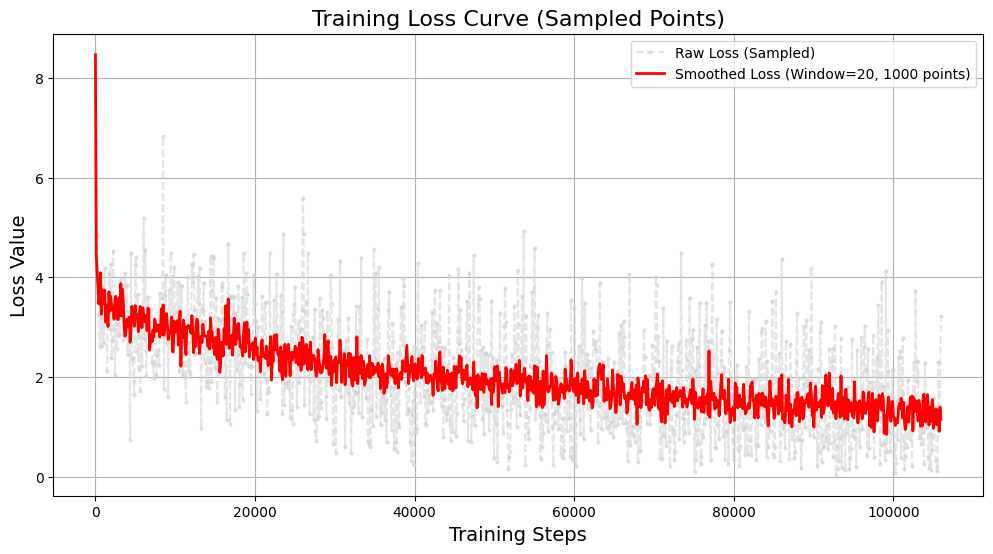

In [79]:
#TASK.2 LSTM
hidden_size = 256
teacher_forcing_ratio=0.5
epochs = 5
save_checkpoints_path='./checkpoints/task2'
plot_loss_path='./checkpoints/task2'
#to conotinue from interrupted process 注释以下两行来阻止编码器和解码器初始化
encoder_lstm = Encoder_LSTM(input_lang.n_words, hidden_size).to(device)
dncoder_lstm = Decoder_LSTM(hidden_size, output_lang.n_words).to(device)

trainIters(teacher_forcing_ratio=teacher_forcing_ratio, encoder=encoder_lstm, decoder=dncoder_lstm,
           epochs=5, print_every=5000, plot_loss_path=plot_loss_path, learning_rate=0.01,save_checkpoints_path=save_checkpoints_path)

In [82]:
hidden_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = './checkpoints/task2/checkpoint_epoch_4.pth'

encoder_lstm = Encoder_LSTM(input_lang.n_words, hidden_size).to(device)
dncoder_lstm = Decoder_LSTM(hidden_size, output_lang.n_words).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
encoder_lstm.load_state_dict(checkpoint['encoder_state_dict'])
dncoder_lstm.load_state_dict(checkpoint['decoder_state_dict'])

evaluateRandomly(encoder_lstm, dncoder_lstm)
input,gt,predict = inference(encoder_lstm, dncoder_lstm, test_pairs)
eval(gt, predict)

> je n ai pas la memoire des noms .
= i m not good at remembering names .
< i m not a little names . <EOS>

> il est deteste de tous .
= he is hated by everyone .
< he s all by . <EOS>

> je suis lent a m adapter a de nouvelles situations .
= i m slow to adapt to new situations .
< i m beginning to get a my . . <EOS>

> nous sommes toujours en forme .
= we re still in good shape .
< we re still alive . <EOS>

> elle n a que deux ans mais elle peut deja compter jusqu a .
= she s only two years old but she can already count to .
< she is two but but she when when she can t . <EOS>

> elles sont froides .
= they re cold .
< they re . . <EOS>

> il est dans la merde .
= he s in big trouble .
< he s in the the . <EOS>

> je suis desolee tom je ne peux pas faire ca .
= i m sorry tom i can t do that .
< i m sorry i can t do that . <EOS>

> elle est infirmiere diplomee .
= she is qualified as a nurse .
< she is a nervous him . <EOS>

> je suis votre amie .
= i m your friend .
< i m your friend

100%|██████████| 2355/2355 [00:11<00:00, 212.96it/s]


=== Evaluation score - Rouge score ===
Rouge1 fmeasure:	 0.6107804775238037
Rouge1 precision:	 0.5820264220237732
Rouge1 recall:  	 0.6503889560699463
Rouge2 fmeasure:	 0.42360973358154297
Rouge2 precision:	 0.3972066044807434
Rouge2 recall:  	 0.4615878164768219


In [ ]:
#task 3 Bi-LSTM E + GRU D